# Historgrams of image data

### Exercises

87 items to plot


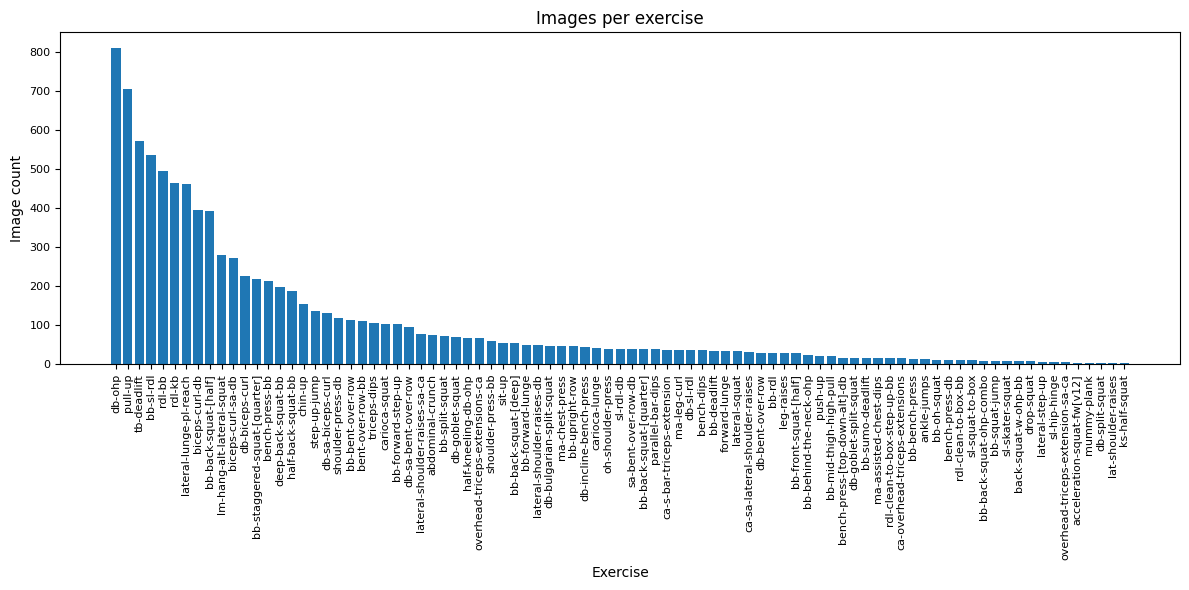

134 items to plot


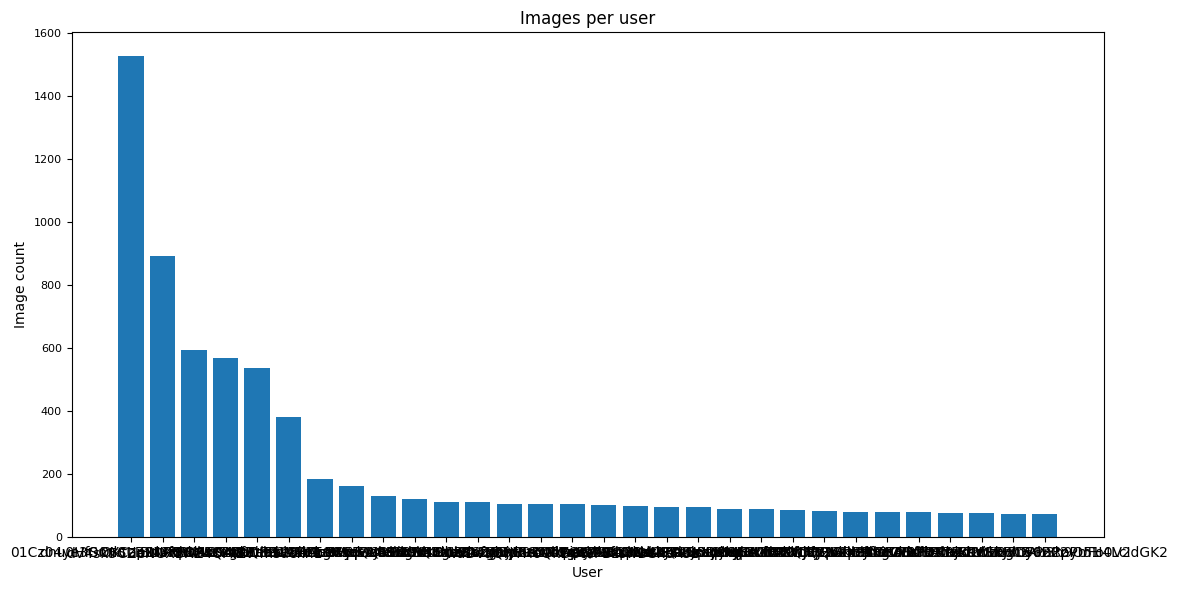

Counter({'01Cz04ye3OOIktLB2NPOGHFC2rs2': 1527, 'dnu0HfSmrSUp0tvYrW9zzTMhQnP2': 892, 'dV4sk5CZeNOXBXZ4QAiZWmsuckn1': 594, 'OXCamd6fqUduaV4SZhCL2WvToas1': 569, 'BMAnhivW3YMrDFehtSii2h9Csqs2': 536, 'RFOAsKxwfHeeNlD4OnYCy53aOPi1': 379, '39d46945-7d5a-44c9-876d-44e8b76c3ce7': 183, 'gSm8IxWEt4cDHpI7V8EodSQ6au82': 161, 'b5L2Ht4z3WeQQIdh8Wa0zriVhAg2': 128, 'l1EgHsqFvJbSO0v4KgIKsYZgojd2': 121, 'ewrYvw30KxN57mzBCfUnru6eYIC2': 110, 'wo413g3HTlbBTVuriDpEG1I6Dpv2': 109, 'uX9dK9Ge2oZEDJtceOaivrnC1a32': 105, 'k5oMe8ac0cRGuD40FqRkANqIhvw2': 104, 'wdDvaQHYHoQkD8teFBzswDSxeRs1': 103, 'V6qB04OdVCetdSfbXXrzhJ7oD8t1': 101, 'nzoVbAiaQkMuDberk2sLVmqsXJJ3': 99, 'Tqg0V504CNbx4QV5sapjI8EZLfE3': 96, 'rYJ7SB1P6dMEOUxXoUxGaGHTOCV2': 93, 'XpuduP8l8jcU2boCA1sFSlhJZ3p2': 88, 'N42EF2N5D8NpBODR9ftHG13kGBY2': 87, 'raaqayP6dHVbVXQjCz2GhmLiuKH3': 85, 'PMkJ6WdRVlYOfJQ6inbbbsE4DGb2': 81, 'sprxwAbwhRZwDYSfFitOGdH4Uwd2': 80, 'ltHNohVWxKe4HLVkirPB57BdLOh2': 79, 'QJ3u1pSSV6ZIFfr7Ti9Z1UiuFRC3': 77, 'Vek2JmzUYbTlcRhj8PWzogC60B22'

In [ ]:
import os
from collections import Counter
import matplotlib.pyplot as plt

image_dirs = [
    r"D:\Magistrska\blindoff-dataset\images",
    # r"D:\Magistrska\blindoff-dataset\selected_images",
]

# Collect unique filenames across both folders (dedupe overlap)
all_files = []
for d in image_dirs:
    if not os.path.isdir(d):
        raise FileNotFoundError(f"Directory not found: {d}")
    for f in os.listdir(d):
        if f.lower().endswith(".jpg"):
            all_files.append(f)

unique_files = set(all_files)

exercise_counts = Counter()
user_counts = Counter()

bad_names = []
for fname in unique_files:
    parts = fname.split("_")
    # Expect: training_id, user_id, exercise_name, set_number, rep_number(.jpg)
    if len(parts) != 5 or not parts[-1].lower().endswith(".jpg"):
        bad_names.append(fname)
        continue

    training_id, user_id, exercise_name, set_number, rep_number = parts

    if len(exercise_name.split("-")[-1]) > 10:
        exercise_name = exercise_name.rsplit("-", 1)[0]

    exercise_counts[exercise_name] += 1
    user_counts[user_id] += 1

if bad_names:
    print(f"Skipped {len(bad_names)} files due to unexpected naming.")
    print("Example(s):", bad_names[:5])


def plot_counter_sorted(
    counter, title, xlabel, ylabel, top_n=None, tick_fontsize=8, disable_x_ticks=False
):
    print(len(counter), "items to plot")
    items = counter.most_common(top_n)  # sorted desc by count
    labels = [k for k, _ in items]
    values = [v for _, v in items]

    plt.figure(figsize=(12, 6))
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # fully vertical labels + smaller text
    if disable_x_ticks:
        plt.xticks([])  # 🔴 disables x-axis ticks completely
    else:
        plt.xticks(rotation=90, fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.tight_layout()
    plt.show()


# Plot 1: images per exercise (sorted)
plot_counter_sorted(
    exercise_counts,
    title="Images per exercise",
    xlabel="Exercise",
    ylabel="Image count",
    top_n=None,  # set e.g. 30 if too crowded
    tick_fontsize=8,
)

# Plot 2: images per user (sorted)
plot_counter_sorted(
    user_counts,
    title="Images per user",
    xlabel="User",
    ylabel="Image count",
    top_n=30,  # bump higher / None if you want all
    tick_fontsize=8,
    disable_x_ticks=True,
)

print(user_counts)